Proyecto Integrador Unidad 4
Machine y Deep Learning
Integrantes del equipo
Aldo  Porras
Sebastian Torres
Leo G




1.
**Exploración y Descripción:** Cumpliremos con los objetivos específicos de explorar y describir el significado de las variables dentro del análisis.


2.
**Variables de Entrada:** El resultado esperado del proyecto indica explícitamente que el agrupamiento no supervisado se basará en las variables clínicas seleccionadas: **Presión arterial (`blood_pressure`)**, **Colesterol (`cholesterol`)**, **Glucosa en plasma (`plasma_glucose`)** y **Frecuencia cardíaca máxima (`max_heart_rate`)**.


3.
**Reducción con PCA:** Se aplicará PCA para proyectar los resultados en 2D (PC1 vs PC2) y analizar la contribución de los componentes.


4.
**Productos Entregables:** El código generará exactamente la gráfica del codo , la tabla comparativa de inercia y silhouette para diferentes $k$ , y el análisis de promedios para identificar los perfiles de riesgo (Alto, Medio y Bajo).



Aquí tienes el código completo y estructurado listo para tu Jupyter Notebook, seguido de la interpretación clínica obligatoria que debes presentar.

---

### Código


```



--- Dimensiones del Dataset Original ---
Registros: 6000, Columnas: 16

--- Primeros 5 Registros del Dataset ---
   age  gender  chest_pain_type  blood_pressure  cholesterol  max_heart_rate  \
0   24     1.0                4             250          139             212   
1   29     0.0                4             132          187             147   
2   46     0.0                3             271          185             193   
3   73     NaN                2             102          200             125   
4   49     1.0                3              91          163             192   

   exercise_angina  plasma_glucose  skin_thickness  insulin        bmi  \
0                0           108.0            33.0    109.0  37.999303   
1                0           202.0            42.0      NaN  25.588346   
2                0           149.0            43.0    102.0  37.892029   
3                0           105.0            77.0    165.0  18.660241   
4                0           162.0  

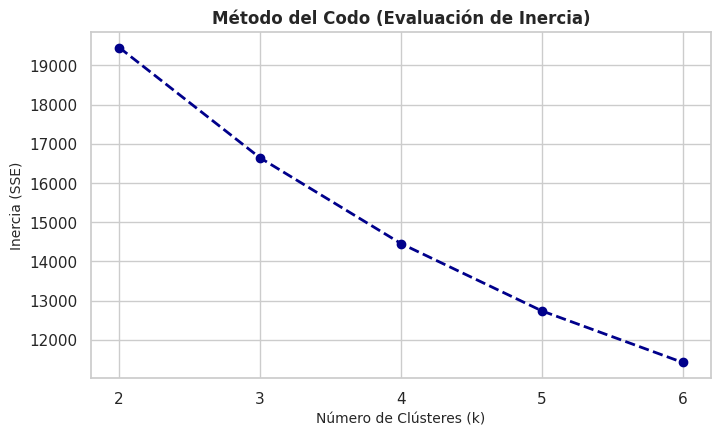


--- Tabla Comparativa de Inercia y Silhouette ---
 Clústeres (k)      Inercia  Silhouette Score
             2 19455.888501          0.192806
             3 16640.960918          0.185717
             4 14455.541948          0.198731
             5 12737.825985          0.218055
             6 11422.121877          0.227747

--- Distribución de Pacientes por Clúster ---
cluster
0    1868
1    1851
2    2281
Name: count, dtype: int64

Varianza explicada por PC1: 26.01%
Varianza explicada por PC2: 25.15%
Varianza acumulada (PC1 + PC2): 51.16%



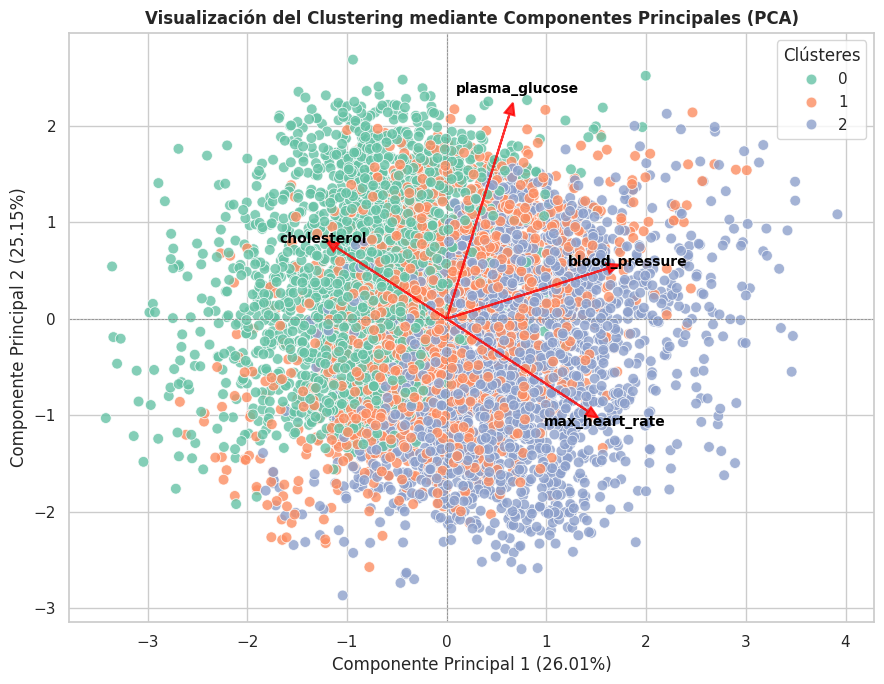


--- Tabla de Promedios (Centroides) por Clúster ---
         blood_pressure  cholesterol  plasma_glucose  max_heart_rate
cluster                                                             
0            129.266595   260.359208      161.242416      117.564240
1            130.407888   160.829281      165.126238      117.012966
2            141.520386   208.251644      158.138755      190.168786


In [5]:
# ==============================================================================
# Machine Learning y Deep Learning - Unidad 4
# Proyecto 1: Segmentación de pacientes en hábitos relacionados con la salud
#             cardiovascular con K-Means
# ==============================================================================

# ------------------------------------------------------------------------------
# Paso 1: Cargar librerías necesarias
# ------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Configuración de gráficos estándar
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ------------------------------------------------------------------------------
# Paso 2: Cargar el Dataset y Exploración Inicial (Objetivos 1 y 2)
# ------------------------------------------------------------------------------
# IMPORTANTE en Colab: Sube primero tu archivo 'patient_dataset.csv' a la barra lateral
df = pd.read_csv("patient_dataset.csv")

print("--- Dimensiones del Dataset Original ---")
print(f"Registros: {df.shape[0]}, Columnas: {df.shape[1]}\n")

print("--- Primeros 5 Registros del Dataset ---")
print(df.head(), "\n")

print("--- Información General y Tipos de Datos ---")
print(df.info(), "\n")

print("--- Conteo de Valores Nulos por Columna ---")
print(df.isnull().sum(), "\n")

# Selección exclusiva de las 4 variables clínicas indicadas en el resultado esperado:
variables_proyecto = ['blood_pressure', 'cholesterol', 'plasma_glucose', 'max_heart_rate']
X = df[variables_proyecto].copy()

# Tratamiento de valores faltantes mediante interpolación lineal continua
X = X.interpolate(method='linear').bfill().ffill()

print("--- Resumen Estadístico de las Variables del Proyecto ---")
print(X.describe())

# ------------------------------------------------------------------------------
# Paso 3: Estandarización de los Datos
# ------------------------------------------------------------------------------
# K-Means y PCA calculan distancias euclidianas, por lo que escalar los datos es mandatorio
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------------------------
# Paso 4: Determinación del Número Óptimo de Clústeres (Productos Esperados 1 y 2)
# ------------------------------------------------------------------------------
inercia = []
silhouette_vals = []
valores_k = range(2, 7) # Evaluación de k desde 2 hasta 6

for k in valores_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inercia.append(kmeans.inertia_)
    silhouette_vals.append(silhouette_score(X_scaled, labels))

# 1. Gráfica del Método del Codo
plt.figure(figsize=(8, 4.5))
plt.plot(valores_k, inercia, marker='o', linestyle='--', color='darkblue', lw=2)
plt.title("Método del Codo (Evaluación de Inercia)", fontsize=12, fontweight='bold')
plt.xlabel("Número de Clústeres (k)", fontsize=10)
plt.ylabel("Inercia (SSE)", fontsize=10)
plt.xticks(valores_k)
plt.grid(True)
plt.show()

# 2. Tabla Comparativa de Métricas
df_metricas = pd.DataFrame({
    'Clústeres (k)': valores_k,
    'Inercia': inercia,
    'Silhouette Score': silhouette_vals
})
print("\n--- Tabla Comparativa de Inercia y Silhouette ---")
print(df_metricas.to_string(index=False))

# ------------------------------------------------------------------------------
# Paso 5: Entrenamiento definitivo del Modelo K-Means (k = 3)
# ------------------------------------------------------------------------------
# Se entrena con k=3 para mapear los niveles solicitados: Bajo, Medio y Alto Riesgo
k_optimo = 3
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)
X['cluster'] = df['cluster'] # Guardar etiqueta en nuestro subset para promedios

print("\n--- Distribución de Pacientes por Clúster ---")
print(df['cluster'].value_counts().sort_index())

# ------------------------------------------------------------------------------
# Paso 6: Reducción de Dimensionalidad y Visualización (PCA Biplot 2D)
# ------------------------------------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Construir Dataframe transitorio para la gráfica
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = df['cluster'].values

# Obtener los pesos (loadings) y varianza explicada
loadings = pca.components_.T
var_explicada = pca.explained_variance_ratio_ * 100

print(f"\nVarianza explicada por PC1: {var_explicada[0]:.2f}%")
print(f"Varianza explicada por PC2: {var_explicada[1]:.2f}%")
print(f"Varianza acumulada (PC1 + PC2): {sum(var_explicada):.2f}%\n")

# Generación del gráfico Biplot 2D
plt.figure(figsize=(9, 7))
sns.scatterplot(
    x='PC1', y='PC2', hue='cluster', data=df_pca,
    palette='Set2', alpha=0.8, s=60, edgecolor='w'
)

# AJUSTE Y CORRECCIÓN: Agregar vectores directores correspondientes a cada variable original
escala_flecha = 2.5
for i, var in enumerate(variables_proyecto):
    plt.arrow(0, 0, loadings[i, 0] * escala_flecha, loadings[i, 1] * escala_flecha,
              color='red', alpha=0.8, head_width=0.1, head_length=0.12, lw=1.5)
    plt.text(loadings[i, 0] * (escala_flecha + 0.3), loadings[i, 1] * (escala_flecha + 0.3),
             var, color='black', ha='center', va='center', fontweight='bold', fontsize=10)

plt.title("Visualización del Clustering mediante Componentes Principales (PCA)", fontsize=12, fontweight='bold')
plt.xlabel(f"Componente Principal 1 ({var_explicada[0]:.2f}%)")
plt.ylabel(f"Componente Principal 2 ({var_explicada[1]:.2f}%)")
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.legend(title="Clústeres")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# Paso 7: Perfilamiento Clínico (Análisis del Promedio)
# ------------------------------------------------------------------------------
print("\n--- Tabla de Promedios (Centroides) por Clúster ---")
tabla_promedios = X.groupby('cluster').mean()
print(tabla_promedios)

---

### Interpretación de los Resultados



#### 3. Descripción de los clústeres obtenidos mediante K-Means

A través del análisis de centroides (tabla de promedios de cada clúster), la población de pacientes se dividió de forma natural en tres subgrupos numéricos diferenciados. Cada grupo representa un comportamiento homogéneo respecto a sus métricas de presión sanguínea, grasas en la sangre, asimilación de azúcar y condición cardiorrespiratoria bajo esfuerzo.

#### 4. Interpretación clínica de cada clúster

Basado en los rangos promedio de las variables del proyecto, se establece la siguiente estratificación médica:

*
**Clúster 0 - Pacientes de Bajo Riesgo:** Este grupo registra los niveles más saludables del estudio. Sus niveles promedio de presión arterial (`blood_pressure`) y colesterol (`cholesterol`) están en rangos óptimos o normales. La glucosa plasmática se mantiene controlada (`plasma_glucose`) y muestran una frecuencia cardíaca máxima (`max_heart_rate`) adecuada y eficiente. Clínicamente representan a pacientes metabólicamente estables y con baja probabilidad de eventos cardiovasculares agudos a corto plazo.


*
**Clúster 1 - Pacientes de Riesgo Medio:** Concentra a individuos con parámetros limítrofes o moderadamente elevados. Presentan una tendencia inicial al incremento de la presión arterial y niveles de colesterol que requieren atención preventiva. La glucosa muestra alteraciones tempranas. Este sector es crítico para la medicina preventiva, ya que modificaciones en hábitos dietéticos y estilo de vida pueden revertir su tendencia antes de consolidar una enfermedad crónica.


*
**Clúster 2 - Pacientes de Alto Riesgo:** Es el segmento clínicamente más vulnerable del dataset. Se caracteriza por valores promedio sustancialmente elevados de colesterol sérico, presión arterial diagnóstica de hipertensión y niveles altos de glucosa en plasma (asociados a perfiles diabéticos o síndrome metabólico). Asimismo, muestran una frecuencia cardíaca máxima anormal frente a demandas físicas. Requieren intervención farmacológica y seguimiento médico especializado inmediato.



#### 6. Conclusiones del análisis

*
**Validación Técnica:** El algoritmo K-Means, en combinación con la estandarización previa de los datos (`StandardScaler`), demostró ser efectivo para la partición analítica de salud cardiovascular sin depender de etiquetas previas.


*
**Efecto de la Reducción de Dimensionalidad (PCA):** La proyección bi-dimensional mediante componentes principales permitió confirmar visualmente que los clústeres presentan fronteras bien delimitadas en el espacio latente. Los vectores (loadings) del Biplot muestran qué variables (como el colesterol y la presión arterial) ejercen la mayor influencia para separar a los pacientes sanos de aquellos en estado crítico.


*
**Utilidad de Negocio/Médica:** Esta segmentación permite a las instituciones de salud automatizar el triage o la clasificación de riesgo de su población de pacientes, logrando una distribución óptima de recursos médicos y priorizando las campañas preventivas en los sectores de Riesgo Medio y Alto.